In [129]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

# ✅ TASK 1: Iris Flower Classification 
 * Use measurements of Iris flowers (setosa, versicolor, virginica) as input data. 
 * Train a machine learning model to classify the species based on these measurements. 
 * Use libraries like Scikit-learn for easy dataset access and model building. 
 * Evaluate the model’s accuracy and performance using test data.

## Loading Dataset

In [130]:
df = pd.read_csv(r'Iris.csv')

## EDA & Data Cleaning

In [131]:
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [132]:
print(f'Rows = {df.shape[0]} \nColumns = {df.shape[1]}')

Rows = 150 
Columns = 6


In [133]:
df.duplicated().sum()

np.int64(0)

In [134]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [135]:
df.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


In [136]:
df.drop(columns = ['Id'], axis = 1, inplace = True)

In [137]:
df.isnull().sum()

SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

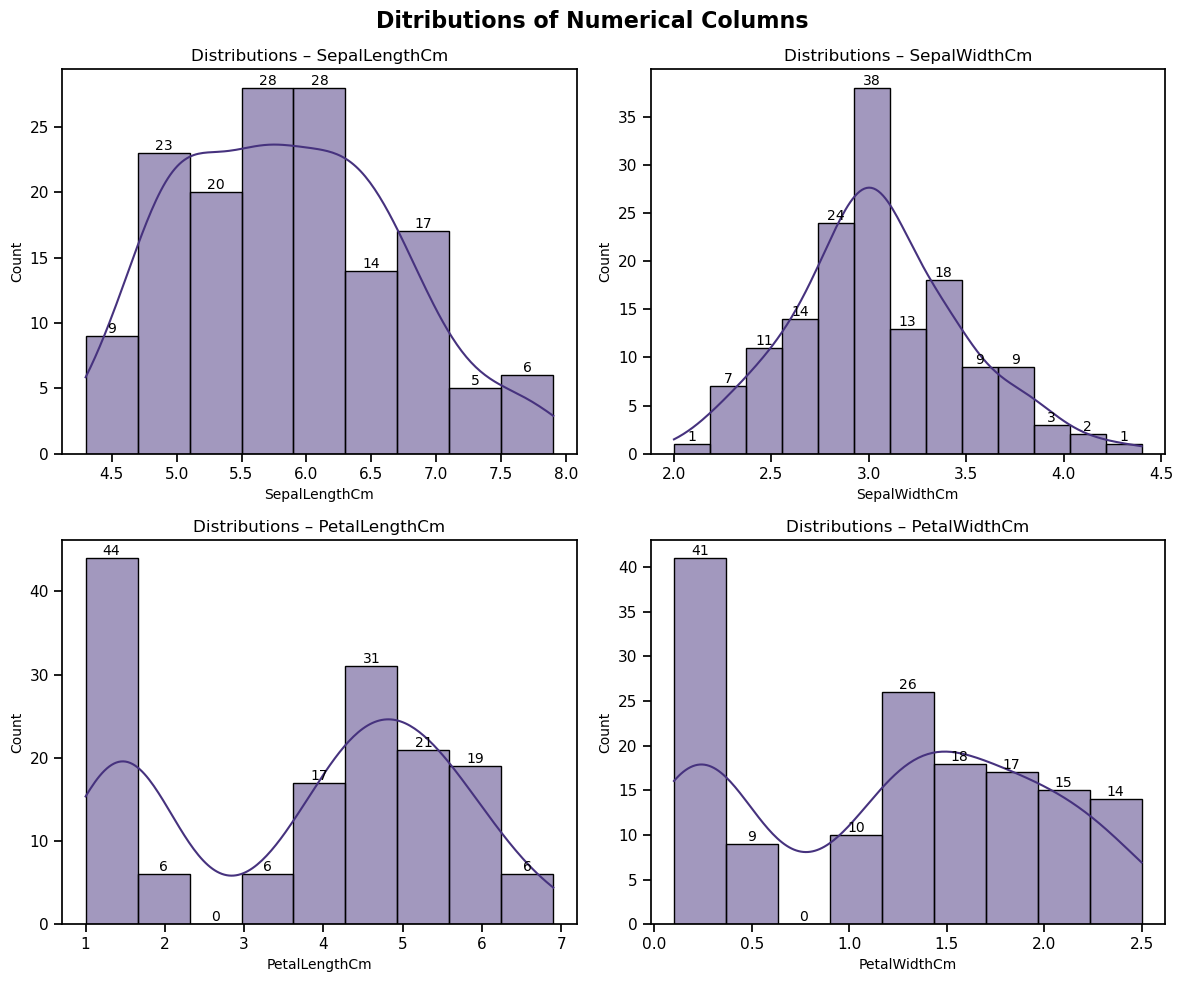

In [138]:
fig, axes = plt.subplots(2, 2, figsize = (12, 10))
axes = axes.flatten()
sns.set_palette('viridis')
sns.set_context('notebook')

columns = df.select_dtypes([int, float]).columns

for i, col in enumerate(columns):
    sns.histplot(
        df[col],
        kde = True,
        ax = axes[i]
    )
    
    axes[i].set_title(f'Distributions – {col}', fontsize = 12)
    axes[i].set_xlabel(col, fontsize = 10)
    axes[i].set_ylabel('Count', fontsize = 10)

    for container in axes[i].containers:
        axes[i].bar_label(container, fmt = '%d', fontsize = 10) 

fig.suptitle('Ditributions of Numerical Columns', fontsize = 16, fontweight = 'bold')

plt.tight_layout()
plt.show()

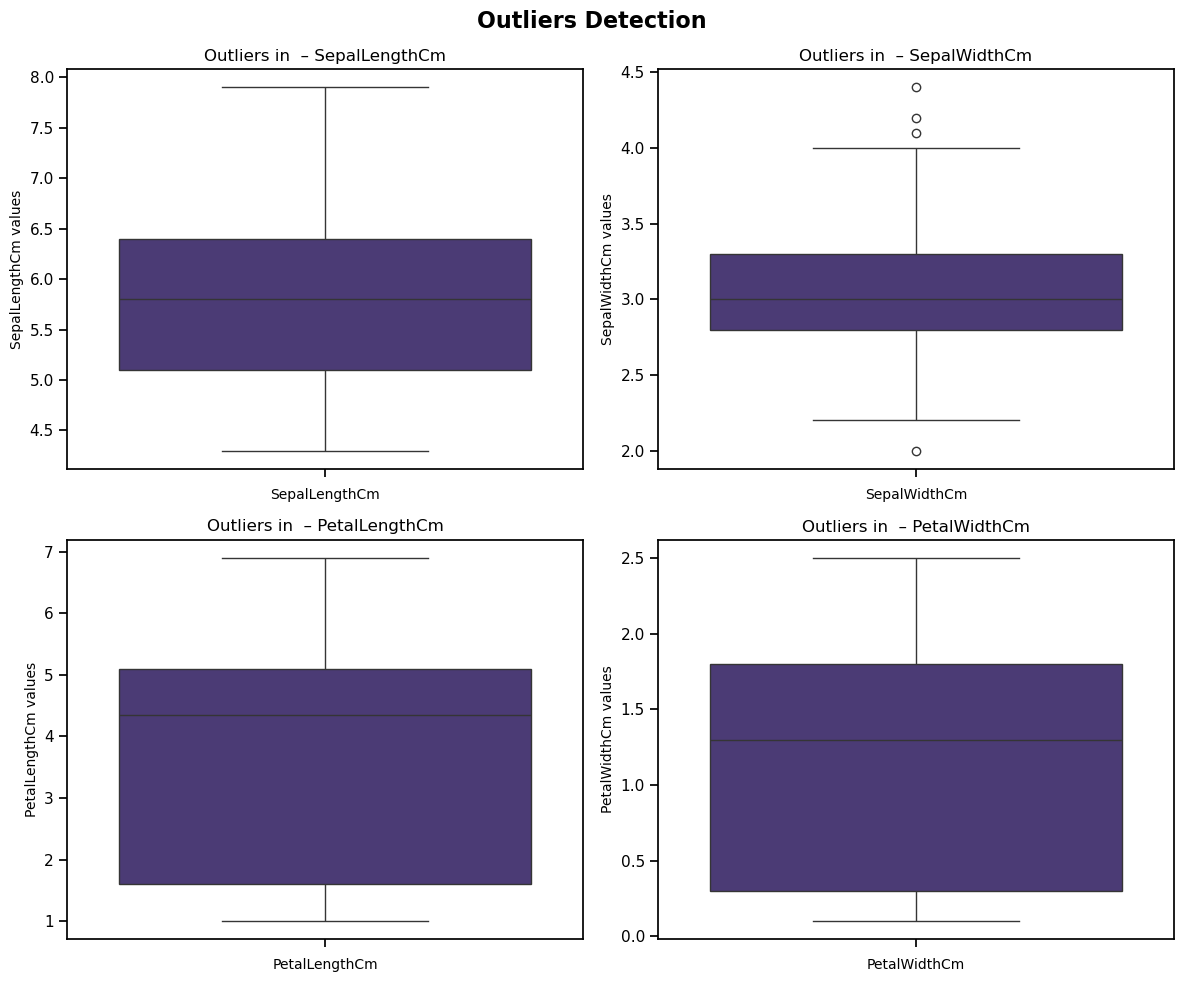

In [139]:
fig, axes = plt.subplots(2, 2, figsize = (12, 10))
axes = axes.flatten()
sns.set_palette('viridis')
sns.set_context('notebook')

for i, col in enumerate(columns):
    sns.boxplot(
        df[col],
        ax = axes[i]
    )
    
    axes[i].set_title(f'Outliers in  – {col}', fontsize = 12)
    axes[i].set_xlabel(col, fontsize = 10)
    axes[i].set_ylabel(f'{col} values', fontsize = 10)
 

fig.suptitle('Outliers Detection', fontsize = 16, fontweight = 'bold')

plt.tight_layout()
plt.show()

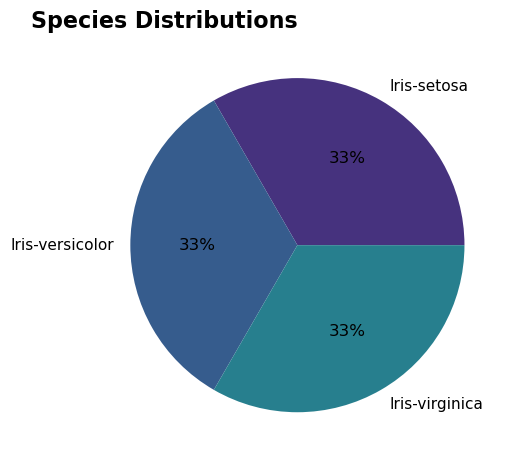

In [140]:
sns.set_palette('viridis')
sns.set_context('notebook')

plt.pie(
    df['Species'].value_counts().values,
    labels = df['Species'].value_counts().index,
    autopct = '%i%%'
)

plt.title('Species Distributions', fontdict = {
    'fontsize' : 16,
    'fontweight' : 'bold',
    'horizontalalignment' : 'right'
})

plt.tight_layout()
plt.show()

In [141]:
unique = df['Species'].unique().tolist()
unique

['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']

In [142]:
df['Species'] = df['Species'].map({
    unique[0] : 0,
    unique[1] : 1,
    unique[2] : 2,
})

In [143]:
df.sample(5)

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
145,6.7,3.0,5.2,2.3,2
36,5.5,3.5,1.3,0.2,0
52,6.9,3.1,4.9,1.5,1
117,7.7,3.8,6.7,2.2,2
101,5.8,2.7,5.1,1.9,2


<Axes: >

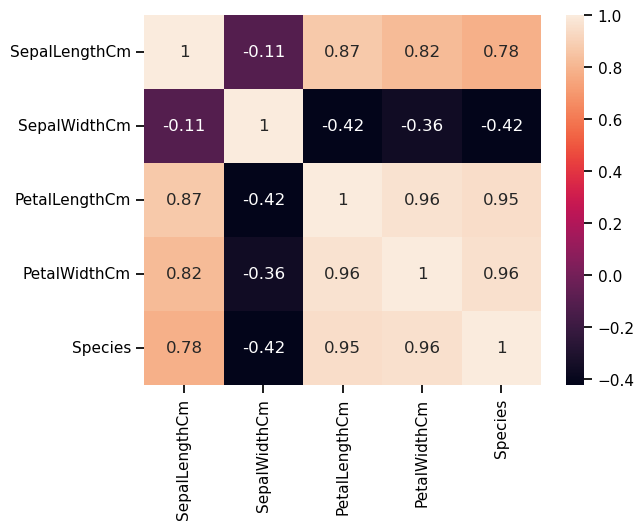

In [144]:
sns.heatmap(df.corr(numeric_only = True), annot = True)

## Train-Test-Split

In [145]:
from sklearn.model_selection import train_test_split

X = df.drop(columns = ['Species'], axis = 1)
y = df['Species']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

## Model Training

In [146]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(max_depth = 3, random_state = 42)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [147]:
y_pred

array([1, 0, 2, 1, 1, 0, 1, 2, 1, 1, 2, 0, 0, 0, 0, 1, 2, 1, 1, 2, 0, 2,
       0, 2, 2, 2, 2, 2, 0, 0])

## Model Evaluation 

In [150]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

acc = accuracy_score(y_test, y_pred)

print("Test Accuracy:", f'{acc * 100}%')
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Test Accuracy: 100.0%

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30


Confusion Matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]
